# **Essential Revenue Forecasts**

### **Objective**
- Build baseline and essential revenue forecasts
- Compare different forecasting assumptions
- Export forecast outputs for downstream visualization and insight generation


### **1) Importing Required Libraries**


In [1]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing


### **2) Loading Monthly Revenue Data**


In [3]:
df = pd.read_csv(
    "../data/processed/monthly_revenue_metrics.csv",
    parse_dates=["revenue_month"],
    dayfirst=True
)

# Convert to monthly period (authoritative monthly index)
df["revenue_month"] = df["revenue_month"].dt.to_period("M")

df.head()


,revenue_month,total_revenue,total_orders,active_customers,avg_order_value,revenue_per_customer
0,2009-12,663272.05,1900,1045,349.090553,634.710096
1,2010-01,531952.90,1296,786,410.457485,676.784860
2,2010-02,489399.58,1335,807,366.591446,606.443098
3,2010-03,635996.48,1907,1111,333.506282,572.454077
4,2010-04,560635.02,1615,998,347.142427,561.758537


### **3) Baseline Preparation (3-Month Moving Average)**


In [4]:
df = df.sort_values("revenue_month")

df["revenue_ma_3"] = df["total_revenue"].rolling(window=3).mean()

df[["revenue_month", "total_revenue", "revenue_ma_3"]].tail()


,revenue_month,total_revenue,revenue_ma_3
20,2011-08,616368.00,5.995399e+05
21,2011-09,931440.37,7.073490e+05
22,2011-10,974603.59,8.408040e+05
23,2011-11,1132407.74,1.012817e+06
24,2011-12,342524.38,8.165119e+05


### **4) Forecast Horizon Definition**


In [5]:
forecast_horizon = 3
last_month = df["revenue_month"].iloc[-1]


### **5) Baseline Forecast (Flat Expectation)**


In [6]:
baseline_value = df["revenue_ma_3"].iloc[-1]

baseline_forecast = pd.DataFrame({
    "revenue_month": pd.period_range(
        start=last_month + 1,
        periods=forecast_horizon,
        freq="M"
    ),
    "revenue": baseline_value,
    "model": "Baseline_MA"
})

baseline_forecast

,revenue_month,revenue,model
0,2012-01,816511.903333,Baseline_MA
1,2012-02,816511.903333,Baseline_MA
2,2012-03,816511.903333,Baseline_MA


### **6) Trend-Based Forecast (Linear Trend)**


In [7]:
df_trend = df.copy()
df_trend["t"] = np.arange(len(df_trend))

# Fit linear regression on time index
coef = np.polyfit(df_trend["t"], df_trend["total_revenue"], 1)

future_t = np.arange(
    df_trend["t"].iloc[-1] + 1,
    df_trend["t"].iloc[-1] + 1 + forecast_horizon
)

trend_forecast = pd.DataFrame({
    "revenue_month": pd.period_range(
        start=last_month + 1,
        periods=forecast_horizon,
        freq="M"
    ),
    "revenue": coef[0] * future_t + coef[1],
    "model": "Linear_Trend"
})

trend_forecast


,revenue_month,revenue,model
0,2012-01,750882.098700,Linear_Trend
1,2012-02,757416.745154,Linear_Trend
2,2012-03,763951.391608,Linear_Trend


### **7) Seasonality-Aware Forecast (Holt-Winters)**


In [8]:
# Convert PeriodIndex to Timestamp for statsmodels
ts = (
    df
    .set_index(df["revenue_month"].dt.to_timestamp())
    ["total_revenue"]
)

hw_model = ExponentialSmoothing(
    ts,
    trend="add",
    seasonal="add",
    seasonal_periods=12
).fit()

hw_forecast_values = hw_model.forecast(forecast_horizon)

hw_forecast = pd.DataFrame({
    "revenue_month": hw_forecast_values.index.to_period("M"),
    "revenue": hw_forecast_values.values,
    "model": "Holt_Winters"
})

hw_forecast


c:\Users\notya\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


,revenue_month,revenue,model
0,2012-01,459712.079864,Holt_Winters
1,2012-02,418885.637282,Holt_Winters
2,2012-03,559306.195500,Holt_Winters


### **8) Combine All Forecast Outputs**


In [9]:
all_forecasts = pd.concat(
    [baseline_forecast, trend_forecast, hw_forecast],
    ignore_index=True
)

all_forecasts


,revenue_month,revenue,model
0,2012-01,816511.903333,Baseline_MA
1,2012-02,816511.903333,Baseline_MA
2,2012-03,816511.903333,Baseline_MA
3,2012-01,750882.098700,Linear_Trend
4,2012-02,757416.745154,Linear_Trend
5,2012-03,763951.391608,Linear_Trend
6,2012-01,459712.079864,Holt_Winters
7,2012-02,418885.637282,Holt_Winters
8,2012-03,559306.195500,Holt_Winters


### **9) Quick Sanity-Check Visualization**


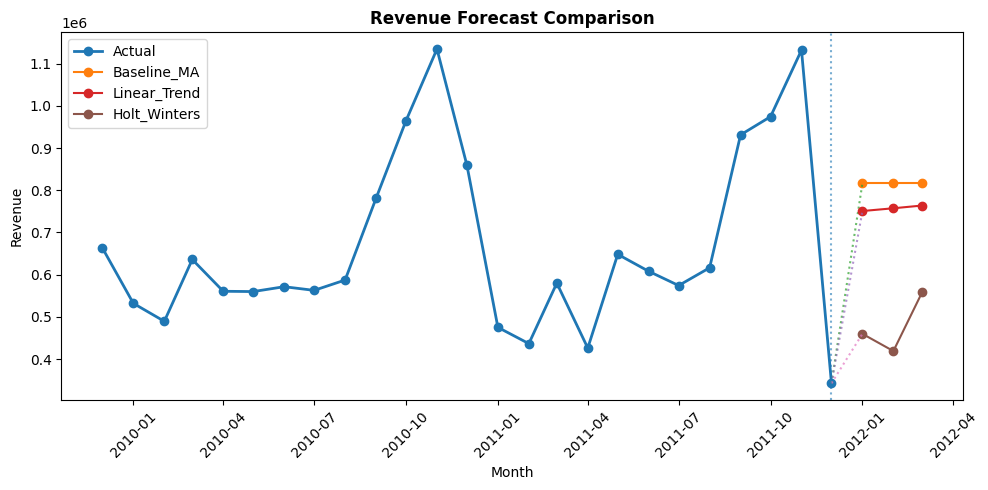

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Convert Periods to timestamps
df["revenue_month_dt"] = df["revenue_month"].dt.to_timestamp()
all_forecasts["revenue_month_dt"] = all_forecasts["revenue_month"].dt.to_timestamp()

# ---- Actuals ----
plt.plot(
    df["revenue_month_dt"],
    df["total_revenue"],
    label="Actual",
    marker="o",
    linewidth=2
)

# Last actual point
last_actual_month = df["revenue_month_dt"].iloc[-1]
last_actual_value = df["total_revenue"].iloc[-1]

# ---- Forecasts + connectors ----
for model in all_forecasts["model"].unique():
    subset = all_forecasts[all_forecasts["model"] == model]

    # Forecast line
    plt.plot(
        subset["revenue_month_dt"],
        subset["revenue"],
        marker="o",
        label=model
    )

    # Connector (dotted)
    first_forecast_month = subset["revenue_month_dt"].iloc[0]
    first_forecast_value = subset["revenue"].iloc[0]

    plt.plot(
        [last_actual_month, first_forecast_month],
        [last_actual_value, first_forecast_value],
        linestyle="dotted",
        linewidth=1.5,
        alpha=0.7
    )

# ---- Vertical split line ----
plt.axvline(
    x=last_actual_month,
    linestyle="dotted",
    alpha=0.6
)

plt.title("Revenue Forecast Comparison",fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


### **10) Export Forecast Outputs**


In [11]:
all_forecasts.to_csv(
    "../data/processed/essential_revenue_forecasts.csv",
    index=False
)